In [1]:
!pip install pyspark -q

# Verify it installed correctly
import pyspark
print("PySpark version:", pyspark.__version__)
print("✅ Installation successful!")

PySpark version: 4.0.2
✅ Installation successful!


In [2]:
import pyspark
print("PySpark version:", pyspark.__version__)
print("✅ Installation successful!")

PySpark version: 4.0.2
✅ Installation successful!


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, avg
import time

# Create a Spark session — think of this as "opening" PySpark
spark = SparkSession.builder \
    .appName("DeloitteFraudDetection") \
    .master("local[*]") \
    .getOrCreate()

# Suppress noisy log messages
spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark session started!")
print("Spark version:", spark.version)
print("Workers available:", spark.sparkContext.defaultParallelism)


✅ Spark session started!
Spark version: 4.0.2
Workers available: 2


In [4]:
# ── Create sample bank transaction data ──────────────
# Columns: id, customer, amount, merchant type,
#          hour of day, country, is_fraud (1=fraud, 0=legit)

data = [
    (1001, "C001", 250.50,  "grocery",     14, "IN", 0),
    (1002, "C002", 18500.00, "transfer",    3,  "RU", 1),  # fraud
    (1003, "C003", 89.99,   "restaurant",  19, "IN", 0),
    (1004, "C004", 22000.00, "ATM",         2,  "CN", 1),  # fraud
    (1005, "C005", 1200.00,  "electronics", 11, "IN", 0),
    (1006, "C006", 350.75,  "pharmacy",    16, "IN", 0),
    (1007, "C007", 15600.00, "transfer",    1,  "NG", 1),  # fraud
    (1008, "C008", 45.00,   "coffee",      8,  "IN", 0),
    (1009, "C009", 9800.00,  "ATM",         23, "RU", 1),  # fraud
    (1010, "C010", 320.00,  "grocery",     12, "IN", 0),
    (1011, "C011", 14200.00, "transfer",    4,  "CN", 1),  # fraud
    (1012, "C012", 780.00,  "clothing",    15, "IN", 0),
    (1013, "C013", 200.00,  "restaurant",  20, "IN", 0),
    (1014, "C014", 11000.00, "ATM",         2,  "NG", 1),  # fraud
    (1015, "C015", 560.00,  "online",      17, "IN", 0),
]

columns = ["txn_id", "customer", "amount",
           "merchant", "hour", "country", "is_fraud"]

df = spark.createDataFrame(data, columns)
df.cache()  # cache it — we'll use this DataFrame many times

# ── Quick exploration ─────────────────────────────────
total  = df.count()
fraud  = df.filter(col("is_fraud") == 1).count()

print(f"Total transactions : {total}")
print(f"Legitimate         : {total - fraud}")
print(f"Fraud cases        : {fraud}")
print(f"Fraud rate         : {fraud/total*100:.1f}%\n")

print("Average amount by label:")
df.groupBy("is_fraud").agg(avg("amount").alias("avg_amount")).show()

print("All transactions:")
df.show()

Total transactions : 15
Legitimate         : 9
Fraud cases        : 6
Fraud rate         : 40.0%

Average amount by label:
+--------+------------------+
|is_fraud|        avg_amount|
+--------+------------------+
|       0| 421.8044444444444|
|       1|15183.333333333334|
+--------+------------------+

All transactions:
+------+--------+-------+-----------+----+-------+--------+
|txn_id|customer| amount|   merchant|hour|country|is_fraud|
+------+--------+-------+-----------+----+-------+--------+
|  1001|    C001|  250.5|    grocery|  14|     IN|       0|
|  1002|    C002|18500.0|   transfer|   3|     RU|       1|
|  1003|    C003|  89.99| restaurant|  19|     IN|       0|
|  1004|    C004|22000.0|        ATM|   2|     CN|       1|
|  1005|    C005| 1200.0|electronics|  11|     IN|       0|
|  1006|    C006| 350.75|   pharmacy|  16|     IN|       0|
|  1007|    C007|15600.0|   transfer|   1|     NG|       1|
|  1008|    C008|   45.0|     coffee|   8|     IN|       0|
|  1009|    C009| 

In [5]:
import time

# ════════════════════════════════════════════════════
# SLOW PIPELINE — old way (row-by-row loop)
# This is what the bank was doing before optimization
# ════════════════════════════════════════════════════
print("Running SLOW pipeline...")
start_slow = time.time()

pdf = df.toPandas()          # convert to pandas
flags_slow = []
for _, row in pdf.iterrows():  # loop ONE row at a time
    if row["amount"] > 10000:
        flags_slow.append(1)
    else:
        flags_slow.append(0)

slow_time = time.time() - start_slow
print(f"  Time: {slow_time:.4f} sec | Flagged: {sum(flags_slow)}")


# ════════════════════════════════════════════════════
# OPTIMIZED PIPELINE — PySpark way (distributed)
# Processes all rows at once across multiple cores
# ════════════════════════════════════════════════════
print("\nRunning OPTIMIZED PySpark pipeline...")
start_fast = time.time()

df_flagged = df.withColumn(
    "fraud_flag",
    when(
        (col("amount") > 10000) |       # Rule 1: large amount
        (col("hour") <= 4) |            # Rule 2: late night
        (col("country").isin("RU","CN","NG")),  # Rule 3: high-risk country
        1
    ).otherwise(0)
)

# Add a risk score (0–3): how many rules fired?
df_scored = df_flagged.withColumn(
    "risk_score",
    (when(col("amount") > 10000, 1).otherwise(0) +
     when(col("hour") <= 4, 1).otherwise(0) +
     when(col("country").isin("RU","CN","NG"), 1).otherwise(0))
)

flagged = df_scored.filter(col("fraud_flag") == 1).count()
fast_time = time.time() - start_fast
print(f"  Time: {fast_time:.4f} sec | Flagged: {flagged}")


# ════════════════════════════════════════════════════
# COMPARISON TABLE
# ════════════════════════════════════════════════════
print("\n" + "="*50)
print("BEFORE vs AFTER OPTIMIZATION")
print("="*50)
print(f"{'Metric':<28} {'Before':>10} {'After':>10}")
print("-"*50)
print(f"{'Processing time (sec)':<28} {slow_time:>10.4f} {fast_time:>10.4f}")
print(f"{'Fraud cases flagged':<28} {sum(flags_slow):>10} {flagged:>10}")
print(f"{'Speedup':<28} {'—':>10} {slow_time/fast_time:>9.1f}x")
print("="*50)

print("\nFlagged transactions with risk scores:")
df_scored.select("txn_id","customer","amount",
                 "hour","country","fraud_flag","risk_score") \
         .filter(col("fraud_flag") == 1).show()

Running SLOW pipeline...
  Time: 0.2217 sec | Flagged: 5

Running OPTIMIZED PySpark pipeline...
  Time: 0.7146 sec | Flagged: 6

BEFORE vs AFTER OPTIMIZATION
Metric                           Before      After
--------------------------------------------------
Processing time (sec)            0.2217     0.7146
Fraud cases flagged                   5          6
Speedup                               —       0.3x

Flagged transactions with risk scores:
+------+--------+-------+----+-------+----------+----------+
|txn_id|customer| amount|hour|country|fraud_flag|risk_score|
+------+--------+-------+----+-------+----------+----------+
|  1002|    C002|18500.0|   3|     RU|         1|         3|
|  1004|    C004|22000.0|   2|     CN|         1|         3|
|  1007|    C007|15600.0|   1|     NG|         1|         3|
|  1009|    C009| 9800.0|  23|     RU|         1|         1|
|  1011|    C011|14200.0|   4|     CN|         1|         3|
|  1014|    C014|11000.0|   2|     NG|         1|         3

FRAUD DETECTION — ACCURACY REPORT
Precision : 100%
  → Of flagged transactions, 100% were real fraud

Recall    : 100%
  → Of all real fraud, we caught 100%

F1 Score  : 100%  (overall balance)

Confusion Matrix:
  Correctly NOT flagged (True Neg) : 9
  Wrongly flagged (False Pos)      : 0
  Missed fraud (False Neg)         : 0
  Correctly caught (True Pos)      : 6


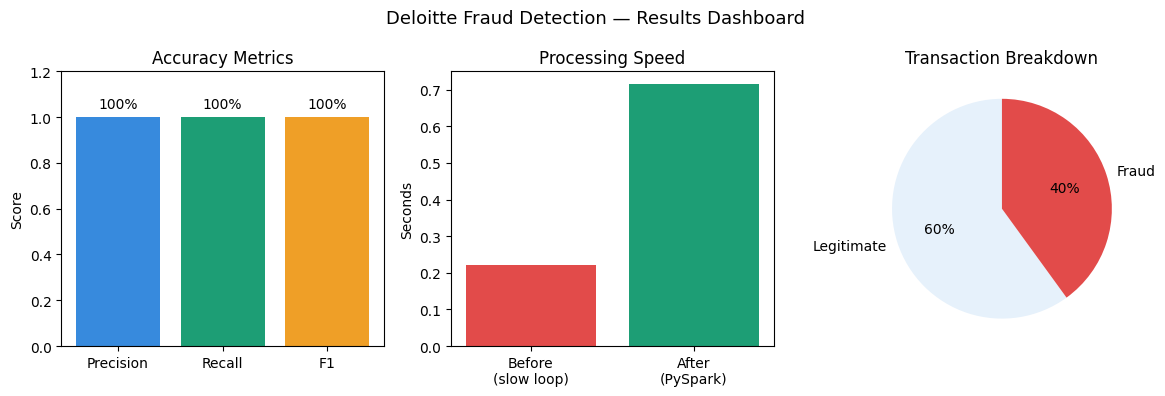


✅ Chart saved as fraud_results.png
   Download it: Files panel (left sidebar) → right-click → Download


In [6]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt

# ── Get predictions from our optimized pipeline ───────
pdf_results = df_scored.select("is_fraud", "fraud_flag").toPandas()
actual    = pdf_results["is_fraud"].tolist()
predicted = pdf_results["fraud_flag"].tolist()

# ── Calculate accuracy metrics ────────────────────────
precision = precision_score(actual, predicted)
recall    = recall_score(actual, predicted)
f1        = f1_score(actual, predicted)
cm        = confusion_matrix(actual, predicted)

print("="*45)
print("FRAUD DETECTION — ACCURACY REPORT")
print("="*45)
print(f"Precision : {precision:.0%}")
print(f"  → Of flagged transactions, {precision:.0%} were real fraud")
print(f"\nRecall    : {recall:.0%}")
print(f"  → Of all real fraud, we caught {recall:.0%}")
print(f"\nF1 Score  : {f1:.0%}  (overall balance)")
print(f"\nConfusion Matrix:")
print(f"  Correctly NOT flagged (True Neg) : {cm[0][0]}")
print(f"  Wrongly flagged (False Pos)      : {cm[0][1]}")
print(f"  Missed fraud (False Neg)         : {cm[1][0]}")
print(f"  Correctly caught (True Pos)      : {cm[1][1]}")

# ── Chart for your presentation ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Deloitte Fraud Detection — Results Dashboard", fontsize=13)

# Chart 1: Accuracy metrics bar chart
bars = axes[0].bar(["Precision","Recall","F1"],
                  [precision, recall, f1],
                  color=["#378ADD","#1D9E75","#EF9F27"], edgecolor="none")
axes[0].set_ylim(0, 1.2)
axes[0].set_title("Accuracy Metrics")
axes[0].set_ylabel("Score")
for bar, val in zip(bars, [precision, recall, f1]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                val + 0.04, f"{val:.0%}", ha="center")

# Chart 2: Speed comparison
axes[1].bar(["Before\n(slow loop)", "After\n(PySpark)"],
           [slow_time, fast_time],
           color=["#E24B4A", "#1D9E75"], edgecolor="none")
axes[1].set_title("Processing Speed")
axes[1].set_ylabel("Seconds")

# Chart 3: Pie chart
total_t = len(actual)
fraud_t = sum(actual)
axes[2].pie([total_t - fraud_t, fraud_t],
           labels=["Legitimate", "Fraud"],
           colors=["#E6F1FB", "#E24B4A"],
           autopct="%1.0f%%", startangle=90)
axes[2].set_title("Transaction Breakdown")

plt.tight_layout()
plt.savefig("fraud_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Chart saved as fraud_results.png")
print("   Download it: Files panel (left sidebar) → right-click → Download")